# 3-2 수업 내용
1. Transformer
2. 파운데이션 모델
3. Transformer 기반, 사물인식 모델
4. Transformer 기반, 이미지 생성 멀티모달 모델
5. Transformer 기반, 그 밖에 멀티모달 모델

# 1. 수업 목표
- 벌써 Transformer 까지 도착했습니다.
  - MLP 시대 -> 딥러닝 시대(CNN) -> Transformer
  - 요즘 딥러닝을 한다고 하면 대부분 Transformer 구조를 택하는 시대입니다.
- 이번 주제는 Transformer / Foundation Model / Multi-Modal Foundation Model입니다.

# 2. 시계열 모델(RNN) 부터 Transformer 까지

### 시계열 데이터와 시계열 모델

- 시간에 흐름 or 순서에 따라 기록된 자료를 **시계열데이터**라고 합니다.
  - 대표적으로 주식차트가 있습니다!
  - 그리고 음성데이터도 있습니다.
  - 그 중 문장도 시계열에 속합니다.
    왜냐면 왼쪽에서 오른쪽 순서로 보아야 의미가 있는 데이터이라서요.

- 시계열 **모델**은 뭘 할수있을까요?
  - 대표적으로 주가 예측을 할수 있습니다. 성능이 좋다면 미래를 예측하여 부자가 될수 있죠.
  - 기온도 예측할 수 있고, 차트로 그릴 수 있는 것은 예측이 가능합니다.
  - 문장에 다음 단어를 예측할 수 도 있어요.

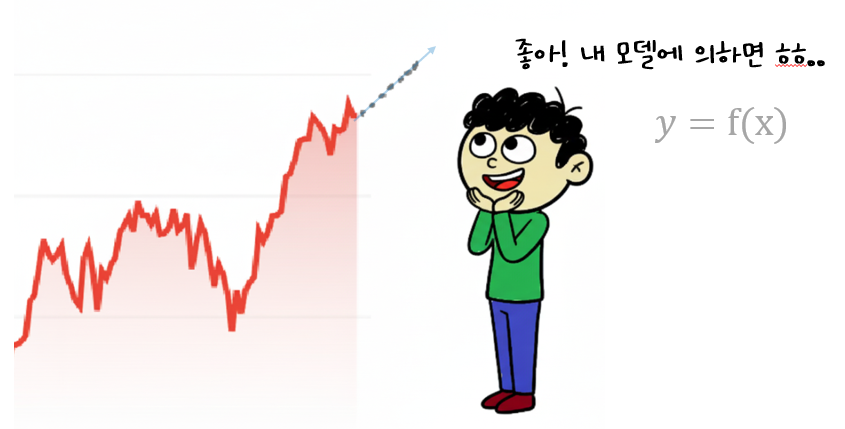

### RNN 모델로 시계열 모델이 시작됩니다.
- RNN(Recurrent Nueral Network)은 아래와 같은 구조를 갖습니다.
  - h는 히든레이어를 표현했습니다. 은닉층은 이전의 MLP 구조에서 ReLU 함수와 비슷한 비선형 함수의 형태입니다.

- 은닉층은 아래와 같은 수식으로 표현할 수 있습니다.
- $h_t = f(W_x x_t + W_h h_{t-1} + b)$

- 결국 RNN의 학습은 최적의 은닉층을 찾아나가는 과정이라고 할 수 있습니다.
    - $W_x$ : 입력을 변환하는 가중치
    - $W_h$ : 과거 상태를 반영하는 가중치
    - $W_y$ : 출력층으로 연결하는 가중치
- 이 세가지를 최적화해서 문맥을 잘 기억하고 예측하도록 만드는 것이 목표입니다.


- 오른쪽 그림을 보시면 히든레이어어 쪽에 뭔가 순환(Recurrent)하죠? 그래서 이름이 Recurrent NN 입니다.

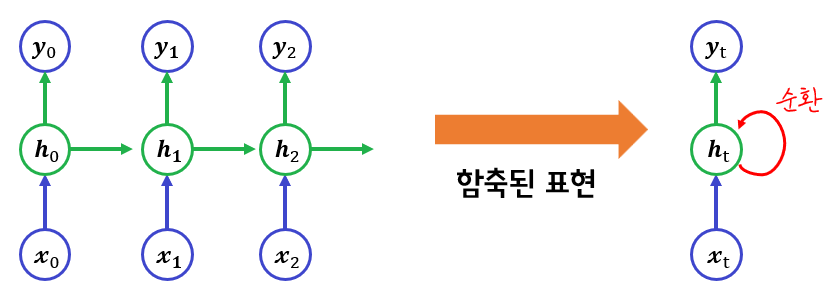

t는 시간의 흐름을 나타냅니다.  

결국 아래와 같이 표현됩니다~.

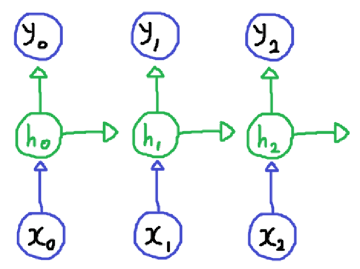

### RNN으로 데이터 학습 원리

- RNN은 이전 시점의 Hidden State의 출력값이, 다음 Hidden State 계산의 입력값으로 들어갑니다.
- RNN의 학습은 다음과 같이 이뤄집니다.
  - **이전 데이터들로 만들어진 정보(Hidden Layer 출력값)를, 다음 글자를 예측하는데 사용됩니다.**

  - 학습할때 입력데이터로 **['안', '녕, '하', '세, '요]** 를 넣어서 학습하겠다고 하겠습니다.

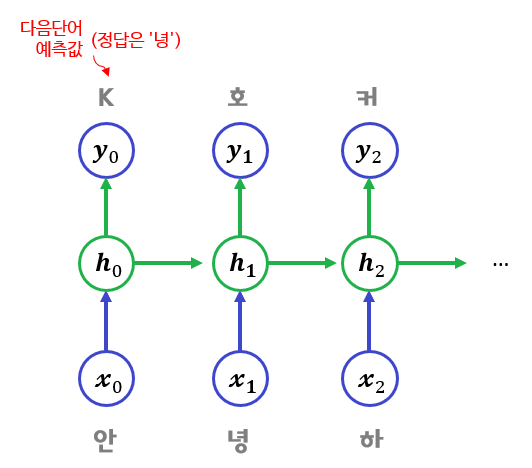

- 나름대로 '안' 다음 글자를 'K'로, 예측했고.. 이런식으로 각각 다음글자를 ['K', '호', '커'] 로 예측이 잘 안되었습니다.
- 이후에 GD를 통해, 오차율이 적도록 히든레이어 가중치 값이 업데이트 됩니다.
  - 그러면 점점 예측을 잘하게 될 것입니다.

- 아래 그림은 epoch을 반복해서 점점 똑똑해졌을 때.. 학습하고 있는 이미지입니다.
  - '녕' 까지는 예측이 잘 되었고, '!' 랑 'ㅋ' 는 오류가 있네요.

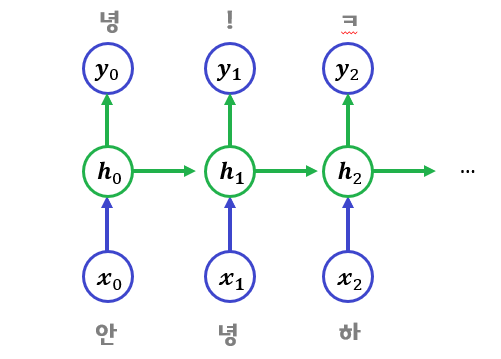

### RNN으로 추론 원리

- 학습이 완료되면 이제 추론에 사용됩니다.
  - 입력 데이터는 이거 하나면 됩니다. ['안'] 한글자요.
  - 그러면 다음 글자들이 연속적으로 예측할 수 있습니다.
  
- 아래 gif는 추론을 하는 예시입니다.

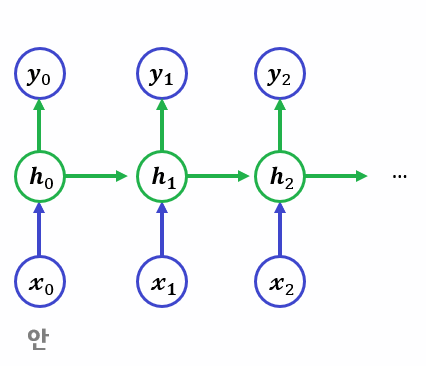

- 만약 추론할때 '안' 한글자가 아니라 '안녕요' 이후 다음문장을 예측하고 싶다면?
  - '안'을 입력으로 넣고, 고의적으로 출력 '녕'을 선택하고,
  - '녕'을 입력으로 넣고, 고의적으로 출력 '요'을 선택하고,
  - '요'을 입력으로 넣고, 이제부터는 RNN이 출력하는 것을 따르면 됩니다.



<br/>

- RNN 원리를 정리해보겠습니다.
  - RNN의 핵심 아이디어는 **이전에 사용했던 정보들을, 다음 단어를 예측하는데 사용** 하는 겁니다.
    - 예측해보고, GD로 점점 에러가적도록 파라미터를 업데이트 합니다.
    - 이후에 실제로 사용할때는 RNN이 추론한 글자들을 출력하면 됩니다.

### RNN의 단점


- Sequence가 길어질수록 초기 정보(Hidden State)들이 반영이 잘안됩니다.
  - 과거 기억을 잊게된다로 비유할 수 있겠습니다.

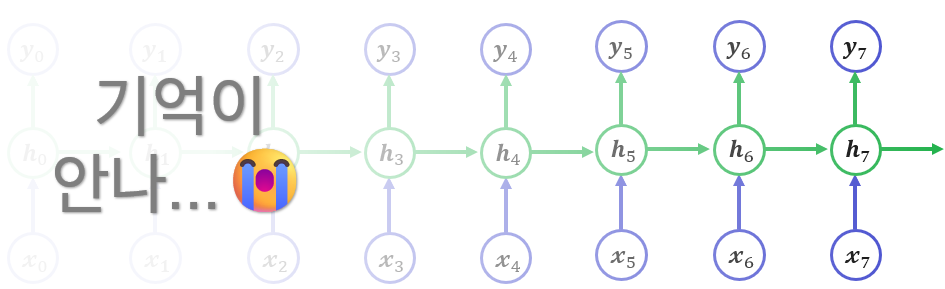

- 또한 Gradient Decent를 하는데 앞 부분은 학습이 잘 되는데, 뒷 부분은 학습이 잘 안됩니다.
  - GD를 위해 기울기 계산 (Backpropagation)을 합니다.
  - 그때 기울기 소실 (점점 0으로 수렴) 문제나, 기울기 폭발 (점점 거대한 값으로 폭발) 문제가 있습니다.

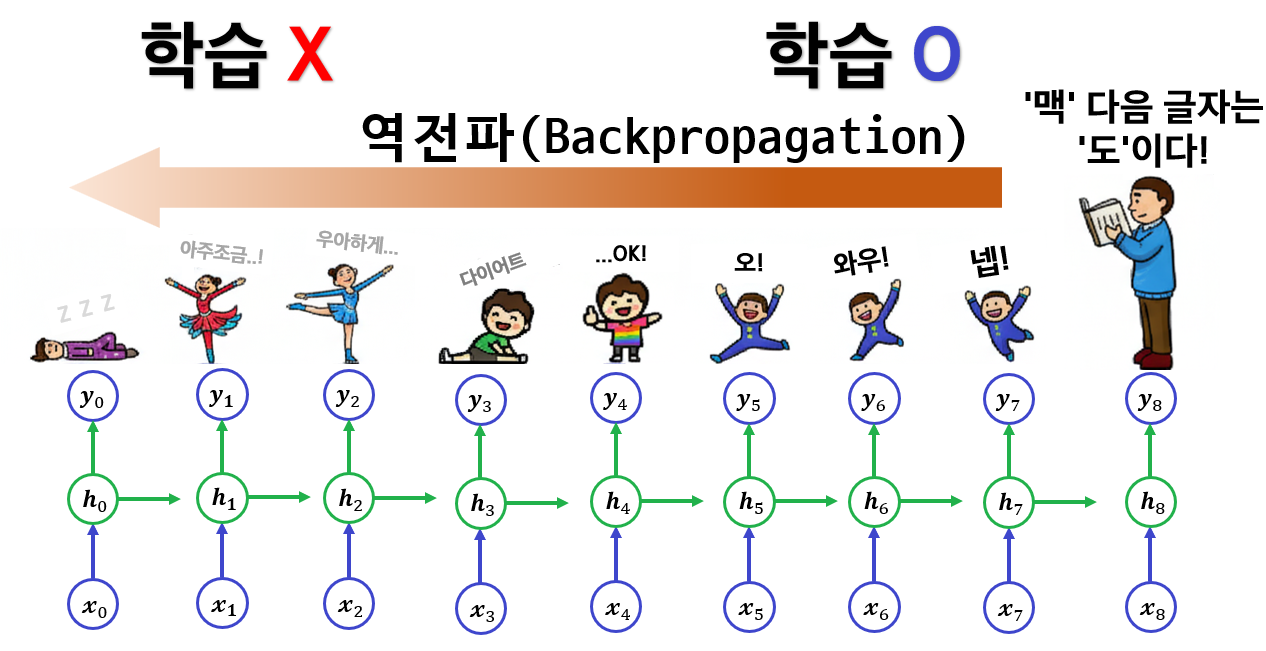

- 기울기 소실, 폭발문제 해결하기 위해 다른알고리즘들(LSTM)이 나왔지만, 여전히 오래전 정보를 잊어버리는 문제는 존재합니다.

## Transformer 모델에서 RNN 단점을 근본적으로 해결!


- 이러한 문제는 **Transformer 모델** 에서 근본적으로 해결되었습니다
- Transformer는 RNN처럼 과거 정보를, 다음 Layer로 전달해주는 방식을 버렸어요.
  - 참고로 RNN은 이전 Hidden Layer값이 모든 과거 정보를 내포하고 있었죠.
  - Transformer 모델은 입력값들의 정보들을 모두 참고하여 다음 Layer의 출력값을 만들어냅니다!
    - 장기기억 소실문제가 해결되었습니다.
    - 기울기 소실, 폭발 문제가 해결되었습니다.
    - 현대 딥러닝은 대부분 Transformer 모델을 기반으로 사용합니다




# 2. Attention과 Transformer 모델
- 시계열 모델(RNN 등) 한계를 극복하기 위해 탄생했습니다.
- Transformer는 Attention을 여러개 사용하는 모델입니다.
  - 일단 Attention이 무엇인지부터 보시죠.



### Attention
- 각 단어가 다른 단어들과 유사한 정도를 계산합니다.
- 이 유사성 정보들을 합쳐서, "문맥 표현 공간"의 벡터값을 계산합니다.

$\huge X_{임베딩들} \xrightarrow{\text{Attention}} Y_{\underline{\color{red}{문맥표현공간}}}$



- 더 정확히 말하면 다음과 같습니다.
  - 그 동안 일반적인 선형계산에는 우리는 y = WX + b로 계산했죠?
    - 하나의 Weight 행렬을 사용합니다.
  - Attention을 계산할 때는 3개의 Weight 행렬을 사용합니다. 3개는 이름이 있습니다.
    - Query / Key / Value 행렬 입니다.
    - 이 Weight값은 학습에 대상이 됩니다~.

<br/>

- 그럼 아래 내용을 봅시다.
  - 복잡한 수식은 건강상 모자이크 처리 했습니다. ^^
  - 각 단어별 "의미공간"의 벡터값인 임베딩 벡터값을 구합니다.
  - 그리고 임베딩 벡터 값들을 각각 $X\cdot W_{query}$, $X\cdot W_{key}$, $X\cdot W_{value}$ 값을 구합니다.
  - 이후에 Attention 수식에 대입하면 output을 구할 수 있습니다.
  - 이 output은 "문맥표현공간"의 벡터값이 됩니다.
    - 엄청난 고차원의 문맥 세계의 입주민이 되는겁니다.

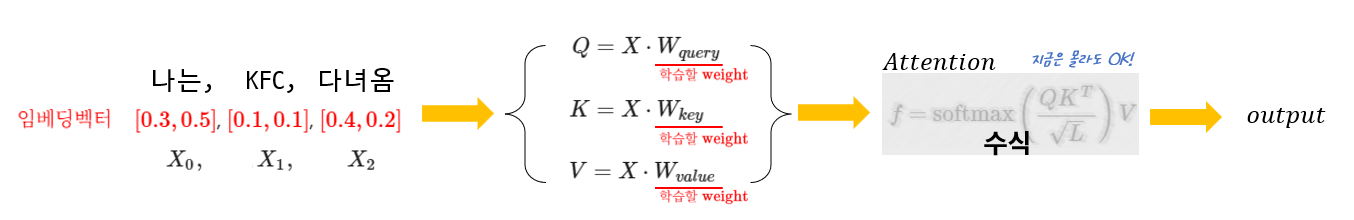

- 위 내용을 요약해보겠습니다.
- 먼저 아래와 같이 Q, K, V 는 각각의 Weight값을 곱한값입니다.
  - 임베딩 값에 선형변환을 한겁니다.

$\huge
\begin{align}
Q &= X \cdot W_{query} \\
K &= X \cdot W_{key} \\
V &= X \cdot W_{value}
\end{align}
$

**Query(Q) : 현재 단어에서 찾고자 하는 의미**  
**Key(K) : 모든 단어가 가지고 있는 의미적 주소(색인, 인덱스)** 
**Value(V) : 그 단어가 실제로 가지고 있는 정보**  

뒤의 수식 설명 : Q와  K의 유사도를 비교해서 그 유사도만큼 V를 가중 평균  
=> 현재 단어(Q)가 다른 단어들(K)들 중에 어떤것과 관련이 있는지를 계산해서 관련  있는 단어들의 핵심 정보(V)를 모아온다.

위 그림에 나온 "나는 KFC에 다녀옴" 라는 문장에서 가장 중요한 단어는 무엇일까요?  
아마 KFC 겠죠. 하지만 여기서 KFC 단어만으로는 아무 의미를 가질 수가 없습니다.  
"나는 KFC" 또는 "KFC에 다녀옴" 이런식으로 다른 단어들과 관계를 계산하여 문맥속에서 어떤 의미를 갖는지 이해해야 합니다.  

이 3개의 파라미터를 학습하게 되어 모델이 무엇을 주목해야 하는지(attention)를 스스로 배우게 됩니다.

그렇다면 Multi-head Attention 은 뭘까요? 무엇이 Multi-head 라는 걸까요?  
=> 입력 벡터를 서로 다른 관점에서 문맥적으로 해석하기 위해서 여러개의 Attention 을 사용

"나는 다녀옴" => 단어 사이의 주체적인 관계의미 해석
"KFC 다녀옴" => 행동적인 관계 의미 해석
문법적 관계, 의미적 유사성, 위치적 관계 등등...  
하나의 Attention 으로는 한가지 기준으로만 단어 사이의 관계를 보기 때문에 이런식으로 단어 사이의  
여러가지 관계는 잘 잡아내기 어려워서, 여러개의 Attention을 병렬로 돌려 서로다른 기준과 서로다른 패턴을 학습하게 합니다.  
그리고 마지막에 결과를 다시 합쳐서 최종적으로 문맥을 잘 이해하게 되는 것입니다.  

Multi-head Attention 은 여러개의 Attention을 가지고 있으므로 각각의 K,Q,V쌍이 여러개 존재합니다.  

- 이후에 수식은 다음과 같이 요약할 수 있습니다.
  - Attention 함수는 아까 모자이크 했던 수식입니다.

$\huge Y_{문맥표현공간} = \color{red}{f_{attention}(Q, K, V)}$

### Transformer 구조
- Transformer의구조는 아래와 같습니다.
  - 출처 : https://en.wikipedia.org/wiki/Transformer_(deep_learning_architecture)

- Tranformer는 Encoder들 + Decoder들 조합으로 구성되어있습니다.
  - Encoder, Decorder 모두 Attention과 MLP의 조합으로 구성되어있습니다.
  - Encoder : 문맥을 이해합니다.
  - Decoder : 입력 문장 정보를 이용해서, 출력 문장을 생성합니다.

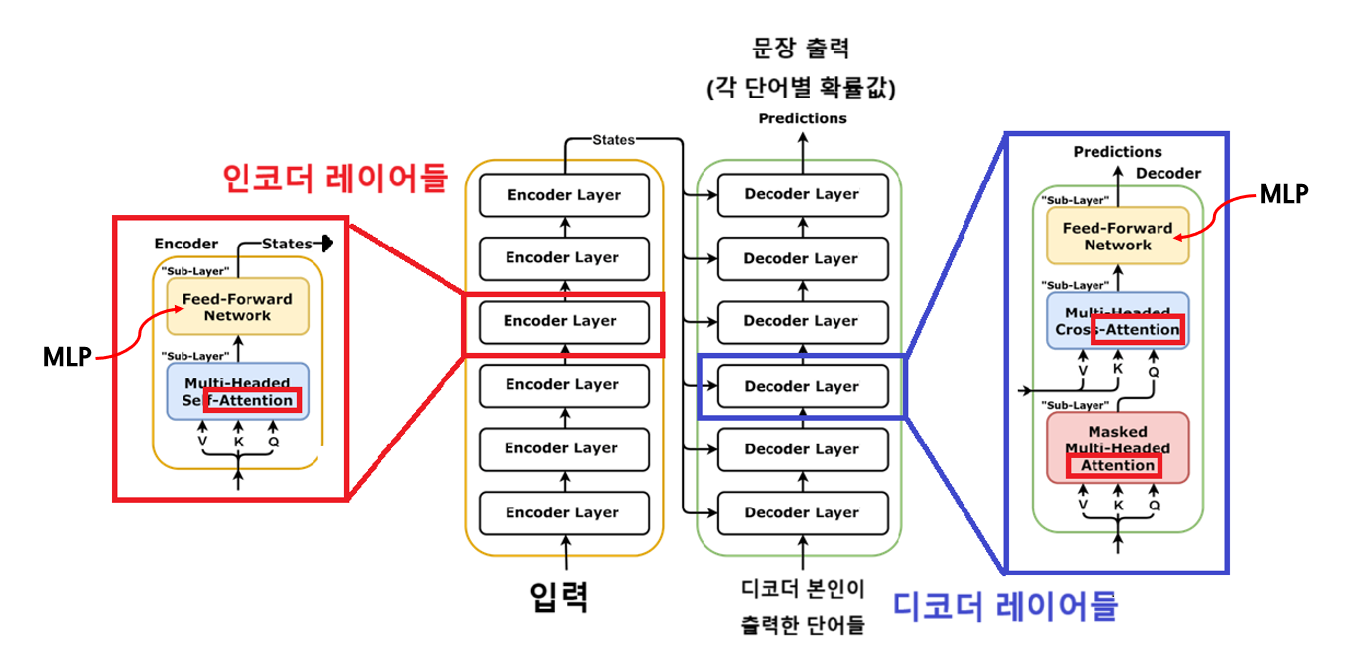

- 요약하면 다음과 같습니다.
  - 입력 문장["I", "love" ,"dogs"] --> [Encoder × N개] --> 문맥 벡터[0.12, -1.03, 0.55, ..., 0,89]
    - Encoder 여러개로 정교한 이해를 합니다.
  - 출력 문장 --> [Decoder × N개] --> 최종 문장 예측
    - Decoder 여러개로 점차 정교한 문장을 만들어냅니다.
    - 입력 : Decoder는 Encoder의 문맥 정보(State)들과 본인이 출력한 단어가 입력됩니다.
    - 출력 : Softmax 값으로, Vocabulary 들 각각 단어가 나올 확률들이 나옵니다.
    - ex) "나는 개를" 다음은? => ["좋아한다" : 0.8, "싫어한다" : 0.1 , ...]

# 3. Transformer 모델을 응용하여 만들 수 있는 것들

### 모달이란?
  - 인간이 정보를 인식할 수 있는 형태를 모달(Modality) 이라고 합니다.
    - Text, Image, Audio, .. 여러 Sensor 값들이 될 수 있습니다.
    - 여러 모달을 다루는 모델을, **멀티모달 모델**이라고 합니다.

### 모달별 Transformer 활용 원리

- Text 모달
  - 문맥 전체를 더 잘 이해하도록 만들 수 있습니다.
  - 문맥에서 벗어나지 않는 문장을 만들어 낼수도 있습니다.

<br/>

- Image 모달
  - 이미지를 작은 단위로 잘라서 하나의 토큰처럼 취급합니다.
    - 이 단위를 패치(patch)라고 합니다.
  - 함께 어울릴 수 있는 패치들을 이해합니다.
    - 이러한 패치들의 조합을 확률 기반으로 선택하여, 자연스러운 이미지 생성할수도 있습니다. (DALL-E 원리)


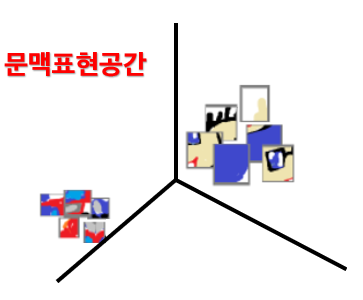


<br/>

- Text와 Image의 유사도 비교
  - Text의 토큰들과, Image의 패치들을 같은 "문맥표현공간"의 벡터 값으로 사용합니다.
  - Image 패치들이, 어떤 Text와 가장 관련이 있는지 알아낼 수 있습니다.
  - 이를 이용하여 사물 인식이 가능합니다.

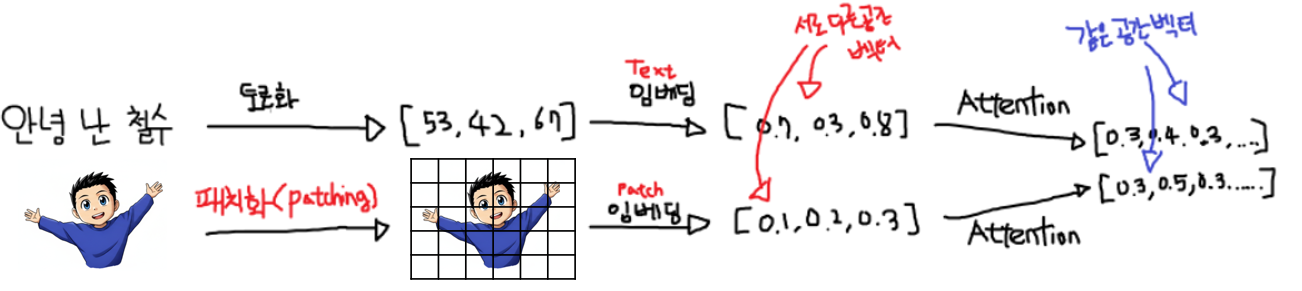

### 모달별 Transformer 활용 사례
  - Text를 입력하면 Image가 생성됩니다.
    - Text to Image 라고 합니다.
    - 예시 : "강아지 사진 만들어줘"
  - Text + Image를 동시에 입력하고, 결과를 받을 수 있습니다.
    - Image-Text to Text 라고 합니다.
    - 예시 : (사진을 주고), "이 사진은 낮이니 밤이니?" 라고 질문 가능합니다.
  - Text를 입력하면, 사람의 음성 Voice를 생성되도록 할 수 있습니다.
    - Text to Speech 라고 합니다.

<br/>

- 아래와 같이 **Transformer 모델이 발표된 이후, 정말 빠르게 Multi-Modal 시대가 되었습니다.**

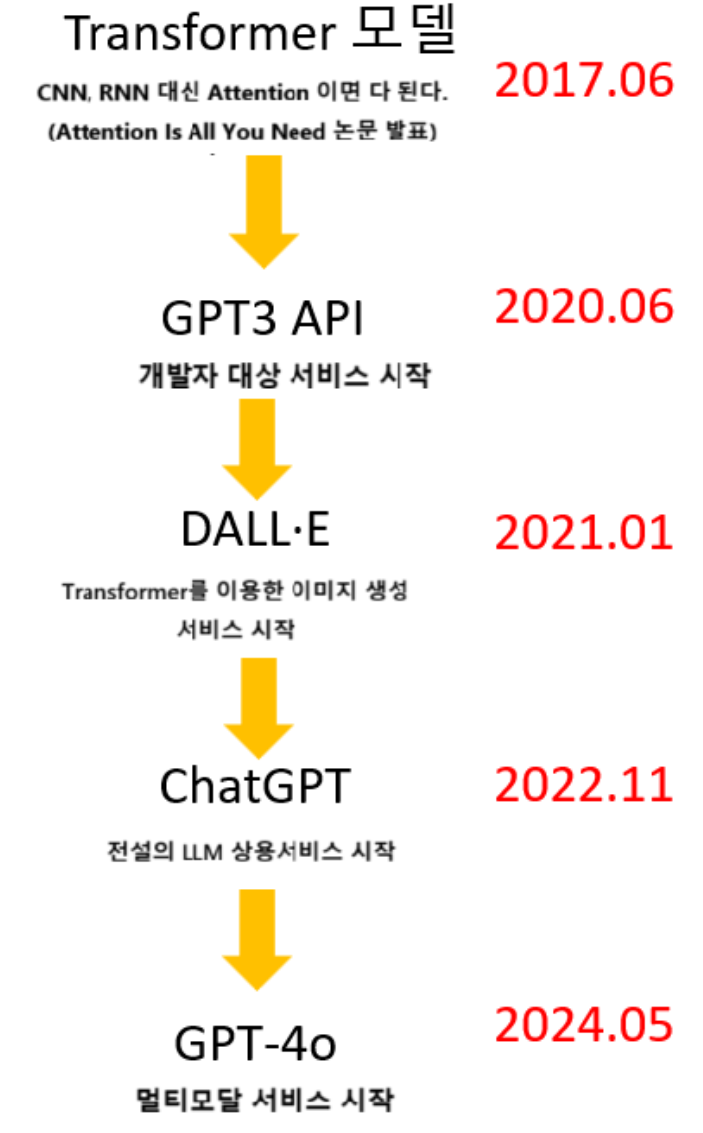

# 4. Foundation 모델

### 파운데이션 모델이란?
- Transformer 이후 시대에는 **Foundation 모델** 이라는 말이 생겼습니다.
- Foundation 모델은 '칭호' 같은 건데요. 다음 조건이 되면 됩니다.
  - **방대한** 범용 데이터로 학습하고
  - 다양한 목적에 맞게 **파인튜닝** 해서 사용 가능한
  - **대규모** 파라미터를 가진 모델

- 근데 방대한의 규모랑, 대규모의 범위는 정해진게 없습니다. ^^
  
<br/>

### 파운데이션 모델 종류 (대표적인 것 위주)
다음은 비공개 모델 입니다.
  - GPT 모델들 (OpenAI)
  - Claude 모델 (Anthropic)
  - Gemini 모델 (Google)

대표적인 공개 모델입니다. (오픈소스, 개인도 파인튜닝 가능)
 - LLaMA (Meta) : 공개 모델의 대표모델이라고 말할 수 있습니다.
 - Qwen (Alibaba) : Qwen3가 25년 4월에 출시되어 매우 인기 많아요.
 - gpt-oss (OpenAI) : 25년 8월 공개함, 연구자에게 매우 인기 많아요.

### 파운데이션 모델 살펴보기

- 허깅페이스에서 모델을 검색해봅시다.
- phi 라고 검색하면 phi-4 multimodal이 눈에 뜁니다.
  - 참고로 허깅페이스에서 멀티모달이라고 써있으면, Image, Text 모두 입력이 가능하다는 의미로 자주 쓰입니다.
  - Image, Text 모두 출력가능한 모델은 거의 없습니다.
  - 참고로 phi4 모델은 코랩 무료버전으로 돌리기 힘들어요. 유료 코랩 사용자만 써보세요.

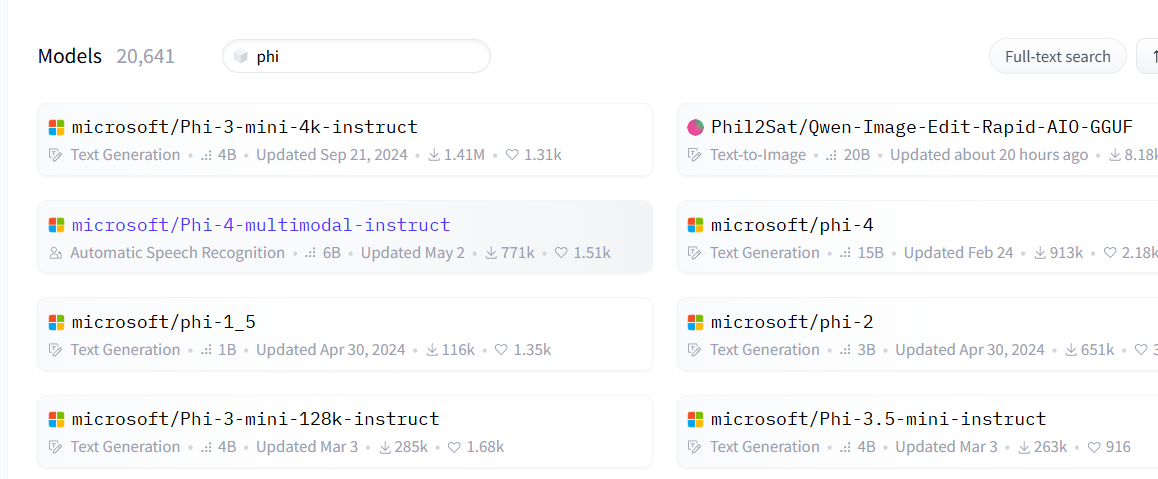

- qwen을 검색해봅시다.
  - Qwen-VL 이 눈에 뜁니다.
  - Vision, Language 라는 의미로 VL이라고 하며 이미지와 언어 동시에 입력받을 수 있는 멀티모달 모델입니다.
- 이렇게 모델마다 이름이 다르고, 멀티모달 모델과 아닌 모델 여러개가 동시에 존재합니다.

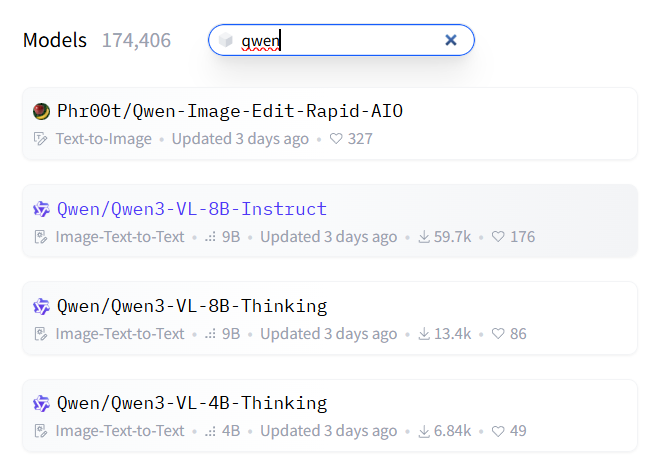

- 이미지 생성모델의 대표주자 중 하나인 Stable Diffusion도 살펴봅시다.
  - 로컬 PC 환경(또는 코랩)에서 이미지를 생성할 수 있습니다.

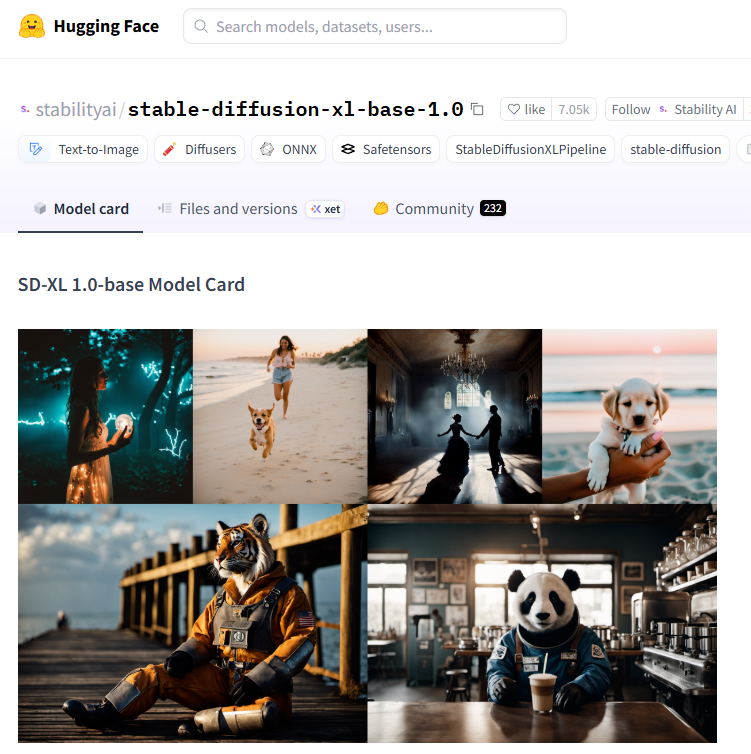

- 그 밖에 허깅페이스에 Models > Tasks 를 눌러서 더 많은 모델을 볼 수 있습니다.
  - Audio-Text-to-Text : 음성 or Text를 이해하는 멀티모달 모델
  - Text-To-Speech : 텍스트를 사람의 음성으로 읽어주는 모델

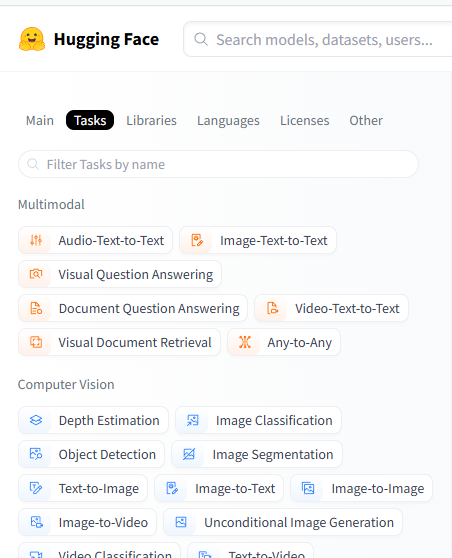

- 여러가지 테스트를 통해 나만의 AI Application을 제작할 수 있겠죠?

# 5. Transformer 기반, 사물인식 모델


- 이미지에서 미리 학습된 객체들을 탐지하는 모델을 돌려보겠습니다.
  - Object Detection 모델이라고 합니다.
- 이제 GPU를 켜주세요.

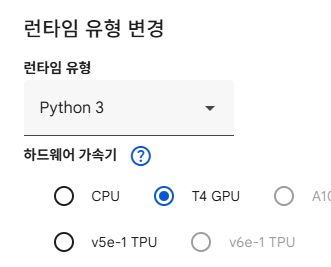

- 사용하는 모델은 Transformer로 만들어진 YOLOS 모델입니다.
  - CNN 기반 모델로 유명한 YOLO 모델은 (You Only Look Once) 이고요.
  - 지금 사용할 Transformer 기반 YOLOS 모델은 (You Only Look at One Sequence) 입니다.
    - 이름을 패러디한거예요.
    - hustvl/yolos-small (https://huggingface.co/hustvl/yolos-small)

  - 먼저 아래 명령어를 수행해서 공개 폰트를 다운로드받아주세요.
    - 이미지에 사물인식 결과를 표시하는데, 폰트가 너무 작아요.
    - 폰트사이즈를 키우려면 따로 폰트파일이 필요하다고 합니다. ^^;

https://github.com/google/fonts/raw/main/ofl/jejugothic/JejuGothic-Regular.ttf

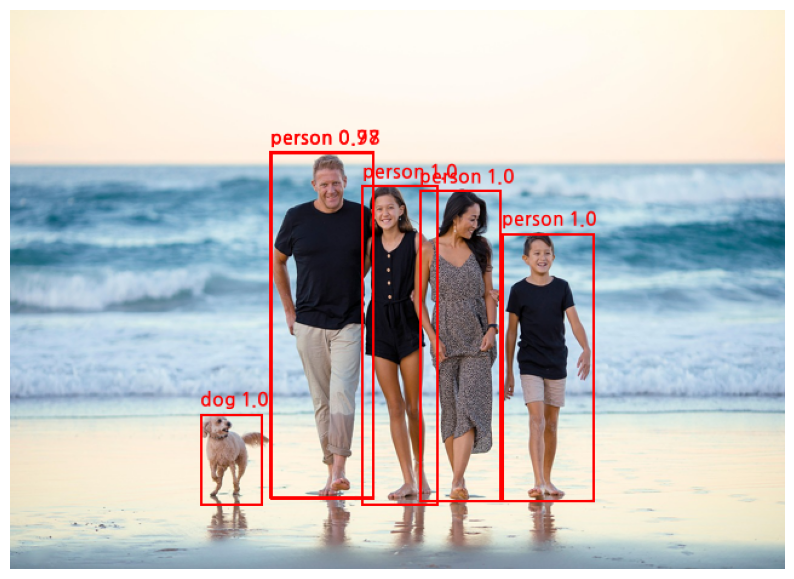

In [1]:
from transformers import YolosImageProcessor, YolosForObjectDetection
import requests
import torch
from PIL import Image, ImageDraw, ImageFont
import matplotlib.pyplot as plt

# 이미지 로드 후 전처리
url = 'https://cdn.pixabay.com/photo/2021/07/09/02/29/family-6398107_1280.jpg'
image = Image.open(requests.get(url, stream=True).raw)
image = image.resize((640, 462))

# 전처리기, 모델 로드
feature_extractor = YolosImageProcessor.from_pretrained('hustvl/yolos-small')
model = YolosForObjectDetection.from_pretrained('hustvl/yolos-small')

# 입력 전처리
inputs = feature_extractor(images=image, return_tensors="pt")

# 모델추론
outputs = model(**inputs)

# 후처리
target_sizes = torch.tensor([image.size[::-1]])
results = feature_extractor.post_process_object_detection(
    outputs, threshold=0.7, target_sizes=target_sizes
)[0]

# 이미지에 바운딩박스 그리기
draw = ImageDraw.Draw(image)
font = ImageFont.truetype("JejuGothic-Regular.ttf", 16)

for score, label, box in zip(results["scores"], results["labels"], results["boxes"]):
    box = [round(i, 2) for i in box.tolist()]
    label_text = f"{model.config.id2label[label.item()]} {round(score.item(), 2)}"

    draw.rectangle(box, outline="red", width=2) # 빨간 사각형
    draw.text((box[0], box[1] - 20), label_text, fill="red", font=font) # 빨간색 글씨

# 결과 시각화
plt.figure(figsize=(10, 10))
plt.imshow(image)
plt.axis("off")
plt.show()

# 6. Transformer 기반, 이미지 생성 멀티모달 모델
- Text to Image 모델로, 이미지를 생성해봅시다.
  - 입력은 Text이고, 출력은 Image 입니다. 두 가지 모달을 사용했으니 멀티모달 모델입니다~.
- 이미지 생성방법인 **Diffusion 알고리즘**은 다음과 같이 동작됩니다.
  - 학습 : 원본 이미지에 노이즈를 조금 추가하고 어디에 얼마나 노이즈를 추가했는지 예측합니다. 이를 반복합니다.
  - 추론 : 완전한 노이즈로 시작해서, 노이즈를 점점 제거하면서 복원하는 방법으로 이미지를 생성합니다.

- 이미지 출처 : https://developer.nvidia.com/blog/understanding-diffusion-models-an-essential-guide-for-aec-professionals/

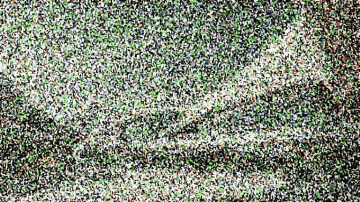

- 다음과 같은 모델을 사용했습니다.
  - "stabilityai/sd-turbo 모델입니다. (Stable Diffusion 2.1)
    - https://huggingface.co/stabilityai/sd-turbo
    - 적은 노이즈 제거 Step으로 빠르게 이미지 생성이 가능한 모델입니다.

model_index.json:   0%|          | 0.00/616 [00:00<?, ?B/s]

c:\Users\SSAFY\AppData\Local\Programs\Python\Python312\Lib\site-packages\huggingface_hub\file_download.py:143: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\SSAFY\.cache\huggingface\hub\models--stabilityai--sd-turbo. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate developer mode, see this article: https://docs.microsoft.com/en-us/windows/apps/get-started/enable-your-device-for-development
  warnings.warn(message)


Fetching 12 files:   0%|          | 0/12 [00:00<?, ?it/s]

config.json:   0%|          | 0.00/618 [00:00<?, ?B/s]

scheduler_config.json:   0%|          | 0.00/553 [00:00<?, ?B/s]

...

special_tokens_map.json:   0%|          | 0.00/574 [00:00<?, ?B/s]

Keyword arguments {'dtype': torch.float16} are not expected by StableDiffusionPipeline and will be ignored.


Loading pipeline components...:   0%|          | 0/5 [00:00<?, ?it/s]

You have disabled the safety checker for <class 'diffusers.pipelines.stable_diffusion.pipeline_stable_diffusion.StableDiffusionPipeline'> by passing `safety_checker=None`. Ensure that you abide to the conditions of the Stable Diffusion license and do not expose unfiltered results in services or applications open to the public. Both the diffusers team and Hugging Face strongly recommend to keep the safety filter enabled in all public facing circumstances, disabling it only for use-cases that involve analyzing network behavior or auditing its results. For more information, please have a look at https://github.com/huggingface/diffusers/pull/254 .


  0%|          | 0/2 [00:00<?, ?it/s]

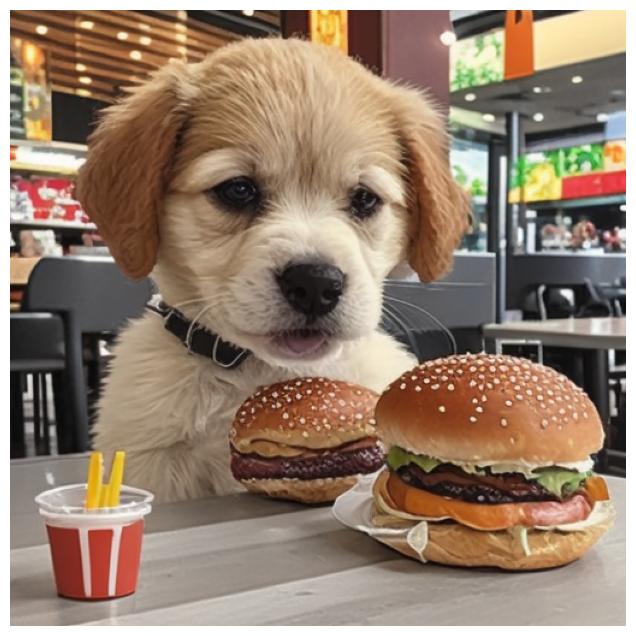

In [2]:
from diffusers import AutoPipelineForText2Image
import torch
import matplotlib.pyplot as plt

pipe = AutoPipelineForText2Image.from_pretrained("stabilityai/sd-turbo", dtype=torch.float16, variant="fp16").to("cuda")

# 프롬프트 입력
prompt = "The puppy is eating a hamburger at McDonald's."

# 이미지 생성
image = pipe(prompt=prompt, num_inference_steps=2, guidance_scale=0.0).images[0]

# 이미지 출력
plt.figure(figsize=(8, 8))
plt.imshow(image)
plt.axis("off")
plt.show()

# 저장
image.save("result.png")


# 7. Transformer 기반, 그 밖에 멀티모달 모델
- 이미지와 텍스트를 입력하여 답변을 요청하는 모델입니다. (Image-Text to Text)
- 모델이름 : HuggingFaceTB/SmolVLM-Instruct
  - https://huggingface.co/HuggingFaceTB/SmolVLM-Instruct

- 오래걸립니다. **다운로드가 약 4.5G 입니다.**
  - 프로젝트에 활용하시는데 도움됩니다. 인내를 가지고 기다려봅시다.
  - 참고로 코랩 다운로드는 여러분 PC의 인터넷 속도와 관련이 없습니다. 코랩 가상머신이 다운로드 받는거니 속도가 빨라요~!

- 아래 예제는 2개의 햄버거 사진과 프롬프트를 주고, 대답을 기다립니다.
  - 프롬프트 : "Can you explain the difference between the two images?

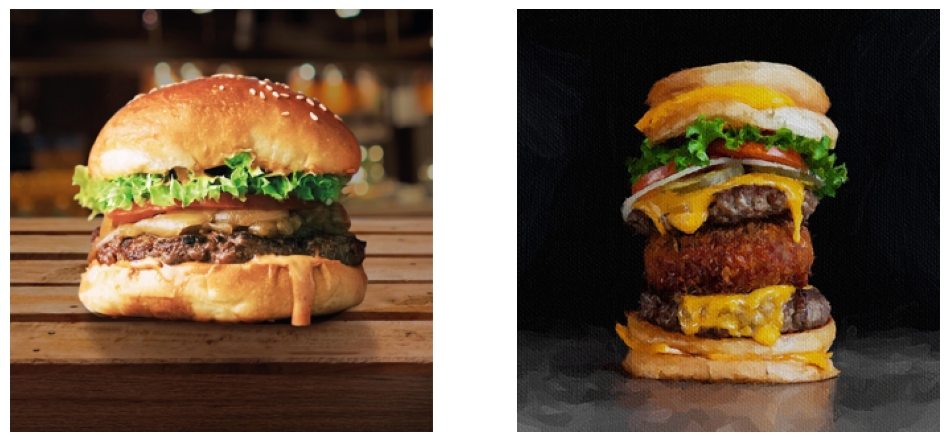

processor_config.json:   0%|          | 0.00/68.0 [00:00<?, ?B/s]

c:\Users\SSAFY\AppData\Local\Programs\Python\Python312\Lib\site-packages\huggingface_hub\file_download.py:143: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\SSAFY\.cache\huggingface\hub\models--HuggingFaceTB--SmolVLM-Instruct. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate developer mode, see this article: https://docs.microsoft.com/en-us/windows/apps/get-started/enable-your-device-for-development
  warnings.warn(message)


chat_template.json:   0%|          | 0.00/429 [00:00<?, ?B/s]

preprocessor_config.json:   0%|          | 0.00/486 [00:00<?, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

...

config.json: 0.00B [00:00, ?B/s]

`torch_dtype` is deprecated! Use `dtype` instead!
Xet Storage is enabled for this repo, but the 'hf_xet' package is not installed. Falling back to regular HTTP download. For better performance, install the package with: `pip install huggingface_hub[hf_xet]` or `pip install hf_xet`


model.safetensors:   0%|          | 0.00/4.49G [00:00<?, ?B/s]

generation_config.json:   0%|          | 0.00/136 [00:00<?, ?B/s]

User:<row_1_col_1><row_1_col_2><row_1_col_3><row_1_col_4>
<row_2_col_1><row_2_col_2><row_2_col_3><row_2_col_4>
<row_3_col_1><row_3_col_2><row_3_col_3><row_3_col_4>
<row_4_col_1><row_4_col_2><row_4_col_3><row_4_col_4>

<global-img><row_1_col_1><row_1_col_2><row_1_col_3><row_1_col_4>
<row_2_col_1><row_2_col_2><row_2_col_3><row_2_col_4>
<row_3_col_1><row_3_col_2><row_3_col_3><row_3_col_4>
<row_4_col_1><row_4_col_2><row_4_col_3><row_4_col_4>

<global-img>Can you explain the difference between the two images?
Assistant: The first image shows a burger with lettuce, tomato, onion, and cheese, while the second image shows a burger with multiple layers of beef patties, cheese, and other ingredients.


In [3]:
import torch
from PIL import Image
from transformers import AutoProcessor, AutoModelForVision2Seq
from transformers.image_utils import load_image
import matplotlib.pyplot as plt

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

# Load images & print
image1 = load_image("https://cdn.pixabay.com/photo/2022/07/15/18/17/spicy-burger-7323694_1280.jpg")
image2 = load_image("https://cdn.pixabay.com/photo/2020/01/28/12/52/burger-4799767_1280.jpg")

image1 = image1.resize((320, 320))
image2 = image2.resize((320, 320))

plt.figure(figsize=(12, 6))

plt.subplot(1, 2, 1)
plt.imshow(image1)
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(image2)
plt.axis("off")

plt.show()


# Initialize processor and model
processor = AutoProcessor.from_pretrained("HuggingFaceTB/SmolVLM-Instruct")
model = AutoModelForVision2Seq.from_pretrained(
    "HuggingFaceTB/SmolVLM-Instruct",
    torch_dtype=torch.bfloat16,
    _attn_implementation="eager",
).to(DEVICE)

# Create input messages
messages = [
    {
        "role": "user",
        "content": [
            {"type": "image"},
            {"type": "image"},
            {"type": "text",

             "text": "Can you explain the difference between the two images?"}
        ]
    },
]

# Prepare inputs
prompt = processor.apply_chat_template(messages, add_generation_prompt=True)
inputs = processor(text=prompt, images=[image1, image2], return_tensors="pt")
inputs = inputs.to(DEVICE)

# Generate outputs
generated_ids = model.generate(**inputs, max_new_tokens=500)
generated_texts = processor.batch_decode(
    generated_ids,
    skip_special_tokens=True,
)

print(generated_texts[0])


# 8. 끝으로
  - Transformer 모델은 Attention들을 이용하여 만들어졌습니다.
  - 이는 Foundation 모델 시대를 열었고, 수 많은 응용으로 AI 시대가 되었습니다.
  - 거의 모든 SW에 AI를 활용할 수 있고, 더 나아가 Physical AI 개념까지 나오고 있습니다.
  - 오늘 수업을 통해 Transformer기반 모델을 다양하게 활용하셔서, 여러분의 프로젝트에 날개가 되길 바랍니다.

<br/>

### Easy 자료 (강사님 자료)
- AI를 처음 공부하는 분들을 위해 만들어져있습니다.
- 내용을 모두 이해해야합니다! **강사님의 도움을 적극적으로 받아주세요.**

### 실습 / 과제 자료 (업스테이지 자료)
- AI를 공부해본 경험자 위주로 만들어져있습니다.
- 퍼즐조각을 모은다는 생각으로 공부해주세요!. **GPT의 도움을 적극적으로 받아주세요.**

### 교수님 강의
- 국내 최고의 AI 교수님들의 강의가 시작됩니다.
- 최대한 내용을 이해해봅시다.
  